<a href="https://colab.research.google.com/github/berrinaydogmus/softito-yapay-zeka/blob/main/MachineLearning3_22_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, classification_report,
                              roc_curve, roc_auc_score)

sns.set_style("whitegrid")
sns.set_context("notebook")
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Veri setini yükle
df = pd.read_csv("ai4i2020.csv", encoding="utf-8-sig")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Veri Seti Boyutu:", df.shape)
df.info()

Veri Seti Boyutu: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64 

In [5]:
#Eksik veri var mı kontrol
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({"Eksik Sayısı": missing, "Eksik Yüzdesi (%)": missing_pct})
missing_report

,Eksik Sayısı,Eksik Yüzdesi (%)
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [6]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns
categorical_cols_all = df.select_dtypes(include="object").columns

for col in numeric_cols_all:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols_all:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Doldurma sonrası toplam eksik değer:", df.isnull().sum().sum())

Doldurma sonrası toplam eksik değer: 0


In [7]:
#EDA
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


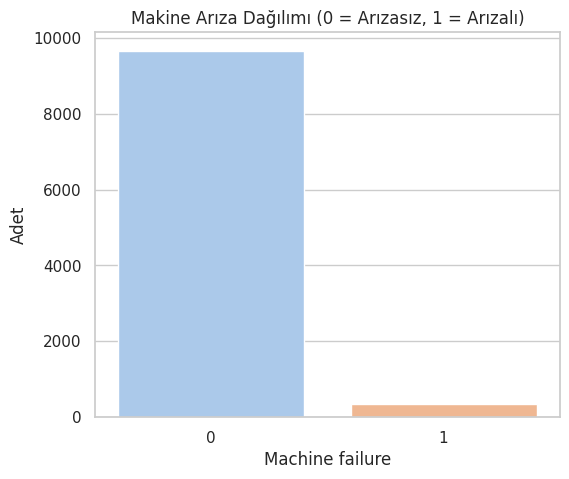

Machine failure
Arızasız    0.9661
Arızalı     0.0339
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,5))
sns.countplot(x="Machine failure", data=df, palette="pastel")
plt.title("Makine Arıza Dağılımı (0 = Arızasız, 1 = Arızalı)")
plt.xlabel("Machine failure")
plt.ylabel("Adet")
plt.show()

print(df["Machine failure"].value_counts(normalize=True).rename(index={0: "Arızasız", 1: "Arızalı"}))

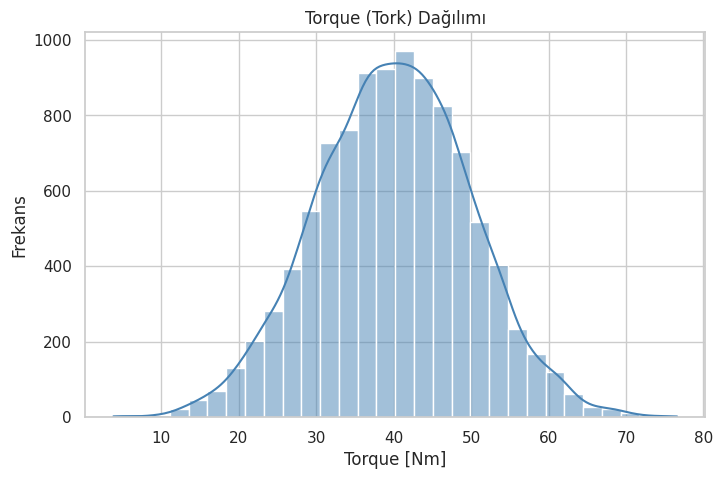

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Torque [Nm]"], bins=30, kde=True, color="steelblue")
plt.title("Torque (Tork) Dağılımı")
plt.xlabel("Torque [Nm]")
plt.ylabel("Frekans")
plt.show()

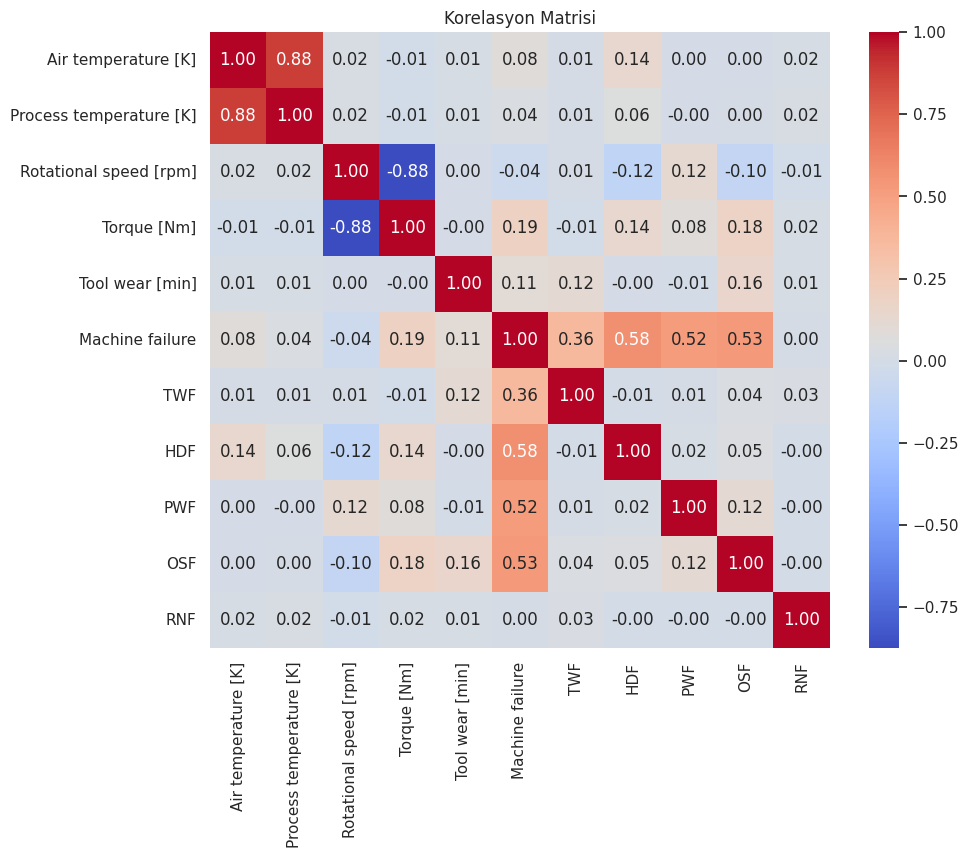

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["UDI"])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

In [11]:
#Ön işleme
df_encoded = pd.get_dummies(df, columns=["Type"], drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded = df_encoded.drop(columns=["UDI", "Product ID"])
df_encoded.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,0


In [12]:
#Lineer Regresyon
feature_cols = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
                "Tool wear [min]", "Type_L", "Type_M"]

X_reg = df_encoded[feature_cols]
y_reg = df_encoded["Torque [Nm]"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

r2_lin = r2_score(y_test, lin_pred)
mae_lin = mean_absolute_error(y_test, lin_pred)
rmse_lin = np.sqrt(mean_squared_error(y_test, lin_pred))

print("Lineer Regresyon Sonuçları")
print("R2:", round(r2_lin, 4))
print("MAE:", round(mae_lin, 4))
print("RMSE:", round(rmse_lin, 4))

Lineer Regresyon Sonuçları
R2: 0.7566
MAE: 3.6866
RMSE: 4.8974


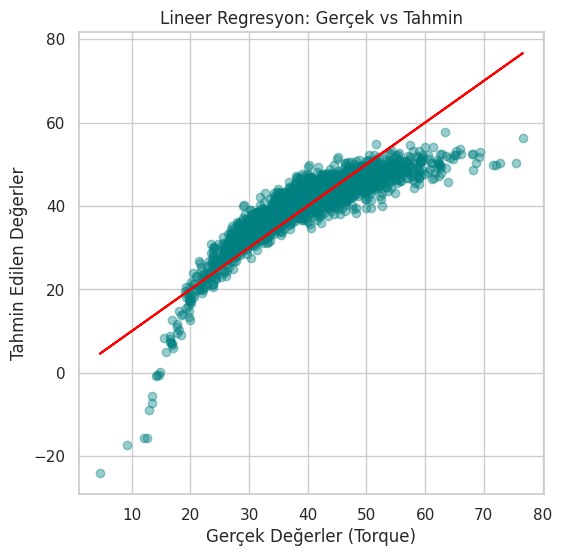

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lin_pred, alpha=0.4, color="teal")
plt.plot(y_test, y_test, "r")
plt.xlabel("Gerçek Değerler (Torque)")
plt.ylabel("Tahmin Edilen Değerler")
plt.title("Lineer Regresyon: Gerçek vs Tahmin")
plt.show()

In [14]:
#Polinom regresyon
poly_features = PolynomialFeatures(degree=2)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
poly_pred = poly_model.predict(X_poly_test)

r2_poly = r2_score(y_test, poly_pred)
mae_poly = mean_absolute_error(y_test, poly_pred)
rmse_poly = np.sqrt(mean_squared_error(y_test, poly_pred))

print("Polinom Regresyon (derece=2) Sonuçları")
print("R2:", round(r2_poly, 4))
print("MAE:", round(mae_poly, 4))
print("RMSE:", round(rmse_poly, 4))

Polinom Regresyon (derece=2) Sonuçları
R2: 0.8332
MAE: 3.0566
RMSE: 4.0548


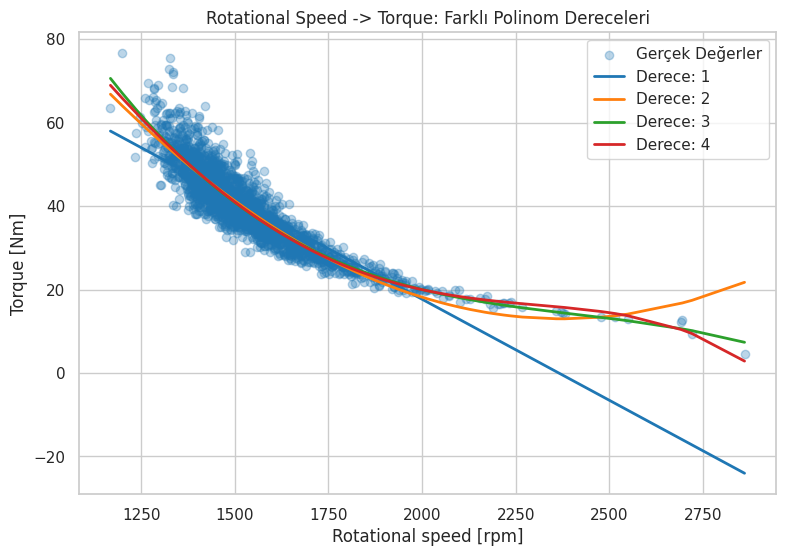

,R2,RMSE
1,0.756910,4.894673
2,0.833459,4.051359
3,0.839260,3.980174
4,0.839146,3.981588


In [15]:
degrees = [1, 2, 3, 4]
poly_results = {}
X_one_train = X_train[["Rotational speed [rpm]"]]
X_one_test = X_test[["Rotational speed [rpm]"]]
sort_idx = X_one_test["Rotational speed [rpm]"].values.argsort()
x_sorted = X_one_test["Rotational speed [rpm]"].values[sort_idx]

plt.figure(figsize=(9,6))
plt.scatter(X_one_test["Rotational speed [rpm]"], y_test, alpha=0.3, color="#1f77b4", label="Gerçek Değerler")
for degree in degrees:
    model_poly_deg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model_poly_deg.fit(X_one_train, y_train)
    poly_pred_deg = model_poly_deg.predict(X_one_test)
    poly_results[degree] = {
        "R2": r2_score(y_test, poly_pred_deg),
        "RMSE": np.sqrt(mean_squared_error(y_test, poly_pred_deg))
    }
    y_line = model_poly_deg.predict(x_sorted.reshape(-1, 1))
    plt.plot(x_sorted, y_line, linewidth=2, label=f"Derece: {degree}")

plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.title("Rotational Speed -> Torque: Farklı Polinom Dereceleri")
plt.legend()
plt.show()

pd.DataFrame(poly_results).T

In [16]:
#Lojistik regresyon
X_clf = df_encoded[feature_cols]
y_clf = df_encoded["Machine failure"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(Xc_train_scaled, yc_train)

y_pred_clf = log_reg.predict(Xc_test_scaled)
y_proba_clf = log_reg.predict_proba(Xc_test_scaled)[:, 1]

accuracy = accuracy_score(yc_test, y_pred_clf)
precision = precision_score(yc_test, y_pred_clf)
recall = recall_score(yc_test, y_pred_clf)
f1 = f1_score(yc_test, y_pred_clf)
auc = roc_auc_score(yc_test, y_proba_clf)

print("Lojistik Regresyon Sonuçları")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC AUC:", round(auc, 4))
print()
print(classification_report(yc_test, y_pred_clf, target_names=["Arızasız", "Arızalı"]))

Lojistik Regresyon Sonuçları
Accuracy: 0.6745
Precision: 0.0745
Recall: 0.75
F1 Score: 0.1355
ROC AUC: 0.7508

              precision    recall  f1-score   support

    Arızasız       0.99      0.67      0.80      1932
     Arızalı       0.07      0.75      0.14        68

    accuracy                           0.67      2000
   macro avg       0.53      0.71      0.47      2000
weighted avg       0.96      0.67      0.78      2000



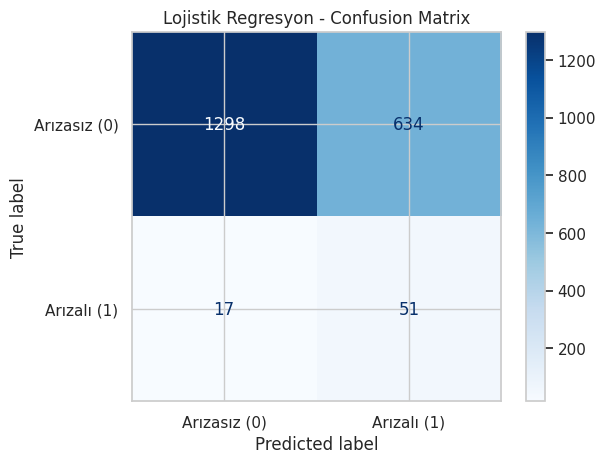

In [17]:
cm = confusion_matrix(yc_test, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Arızasız (0)", "Arızalı (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Lojistik Regresyon - Confusion Matrix")
plt.show()

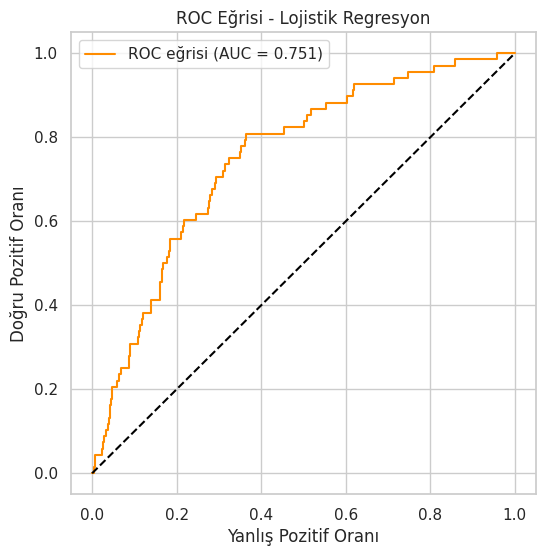

In [18]:
fpr, tpr, _ = roc_curve(yc_test, y_proba_clf)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC eğrisi (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("Yanlış Pozitif Oranı")
plt.ylabel("Doğru Pozitif Oranı")
plt.title("ROC Eğrisi - Lojistik Regresyon")
plt.legend()
plt.show()